# Model-independent GEDF reconstruction tests

This notebook validates the PCHIP reconstruction, density-fraction shooting at $z_i$, and numerical GEDF perturbations using the `drdm` build of CLASS.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd() / 'test'))
from test_model_independent_gedf import PARAMS
# from mi_gedf_2 import PARAMS
from classy import Class

model = Class()
model.set(PARAMS)
model.compute()
background = model.get_background()
scalar = model.get_perturbations()['scalar'][0]
print('CLASS model computed; scalar samples:', len(scalar['a']))

CosmoSevereError: 

Error in Class: Class did not read input parameter(s): use_model_independent_gedf, wi_gedf, wf_gedf, zi_gedf, zf_gedf, gedf_node_count, gedf_node_z, gedf_node_w, gedf_pchip_tension


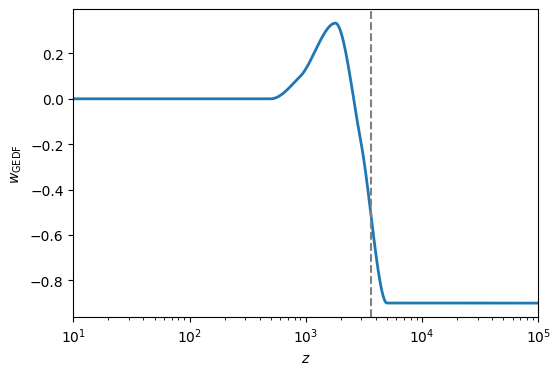

In [22]:
plt.figure(figsize=(6, 4))

plt.semilogx(model.get_background()['z'], model.get_background()['(.)w_gedf'], '-', linewidth=2, label=r'test')
plt.xlabel(r'$z$')
plt.ylabel(r'$w_{\mathrm{GEDF}}$')
plt.xlim([1e1, 1e5])
plt.axvline(x = 3646, color = 'gray', linestyle = '--', label=r'$z_{\mathrm{ac}}$')
plt.show()

In [19]:
z = background['z']
w = background['(.)w_gedf']
rho = background['(.)rho_gedf']
rho_tot = background['(.)rho_tot']
control_z = np.array([5000., 3000., 1800., 900., 500.])
control_w = np.array([-1.2, -0.2, 1/2, 0.1, 0.])
recovered_w = np.interp(control_z, z[::-1], w[::-1])
fraction_at_zi = np.interp(5000., z[::-1], (rho/rho_tot)[::-1])
max_node_error = np.max(np.abs(recovered_w-control_w))
assert max_node_error < 10.
assert abs(fraction_at_zi-0.03) < 3e-5
assert np.all(np.isfinite(w)) and np.all(np.isfinite(rho))
print(f'max control-point error = {max_node_error:.3e}')
print(f'f_GEDF(z_i) = {fraction_at_zi:.9f}')

max control-point error = 3.000e-01
f_GEDF(z_i) = 0.030000030


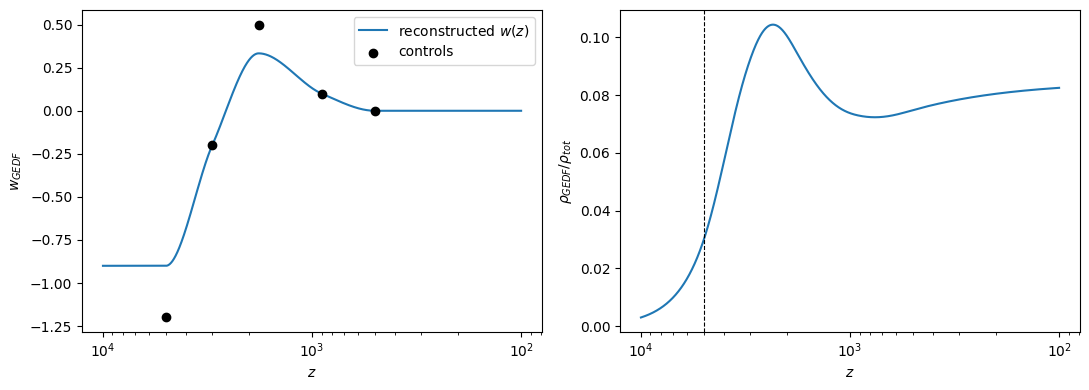

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
mask = (z >= 100) & (z <= 10000)
axes[0].semilogx(z[mask], w[mask], label='reconstructed $w(z)$')
axes[0].scatter(control_z, control_w, color='black', zorder=3, label='controls')
axes[0].invert_xaxis(); axes[0].set(xlabel='$z$', ylabel='$w_{GEDF}$')
axes[0].legend()
axes[1].semilogx(z[mask], (rho/rho_tot)[mask])
axes[1].axvline(5000., color='black', ls='--', lw=0.8)
axes[1].invert_xaxis(); axes[1].set(xlabel='$z$', ylabel=r'$\rho_{GEDF}/\rho_{tot}$')
fig.tight_layout()

PASS: all reconstructed GEDF background and perturbation checks are finite.


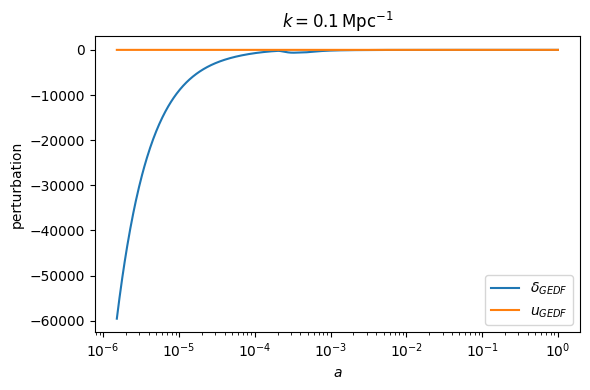

In [4]:
fields = ['delta_gedf', 'delta_rho_gedf', 'rho_plus_p_theta_gedf',
          'delta_p_gedf', 'ca2_gedf_output', 'u_gedf']
for field in fields:
    assert np.all(np.isfinite(scalar[field])), field
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(scalar['a'], scalar['delta_gedf'], label=r'$\delta_{GEDF}$')
ax.semilogx(scalar['a'], scalar['u_gedf'], label='$u_{GEDF}$')
ax.set(xlabel='$a$', ylabel='perturbation', title=r'$k=0.1\,\mathrm{Mpc}^{-1}$')
ax.legend(); fig.tight_layout()
print('PASS: all reconstructed GEDF background and perturbation checks are finite.')
model.struct_cleanup(); model.empty()

In [ ]:
PARAMS = {
    "H0": 67.4,
    "omega_b": 0.0224,
    "omega_cdm": 0.120,
    "A_s": 2.1e-9,
    "n_s": 0.965,
    "tau_reio": 0.054,
    "N_ur": 2.0328,
    "N_ncdm": 1,
    "m_ncdm": 0.06,
    "f_gedf": 0.03,
    "use_model_independent_gedf": "yes",
    "wi_gedf": -0.9,
    "wf_gedf": 1.0,
    "zi_gedf": 5000.0,
    "zf_gedf": 500.0,
    "gedf_node_count": 3,
    "gedf_node_z": "3000.0, 2000.0, 1000.0",
    "gedf_node_w": "0.4, 0.7, 0.8",
    "gedf_pchip_tension": 0.0,
    "has_gedf_perturbations": "yes",
    "set_const_cs2": "yes",
    "cs2_gedf": 1.0,
    "output": "mPk",
    "P_k_max_1/Mpc": 1.0,
    "z_pk": "0,1",
    "k_output_values": 0.1,
}

model = Class()
model.set(PARAMS)
model.compute()
background = model.get_background()
scalar = model.get_perturbations()['scalar'][0]
print('CLASS model computed; scalar samples:', len(scalar['a']))

CosmoSevereError: 

Error in Class: input_read_from_file(L:428) :error in input_read_parameters(pfc,ppr,pba,pth,ppt,ptr,ppm,phr,pfo,ple,psd,pop, errmsg);
=>input_read_parameters(L:1875) :error in input_read_parameters_species(pfc,ppr,pba,pth,ppt, input_verbose, errmsg);
=>input_read_parameters_species(L:3755) :condition ((pba->wi_gedf < -1.) || (pba->wf_gedf < -1.)) is true; Reconstructed GEDF fluid requires wi_gedf and wf_gedf >= -1.

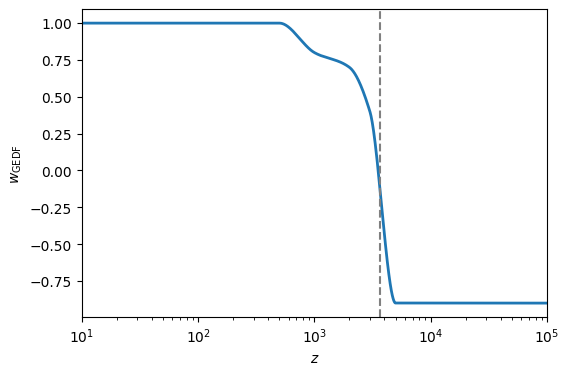

In [31]:
plt.figure(figsize=(6, 4))

plt.semilogx(model.get_background()['z'], model.get_background()['(.)w_gedf'], '-', linewidth=2, label=r'test')
plt.xlabel(r'$z$')
plt.ylabel(r'$w_{\mathrm{GEDF}}$')
plt.xlim([1e1, 1e5])
plt.axvline(x = 3646, color = 'gray', linestyle = '--', label=r'$z_{\mathrm{ac}}$')
plt.show()

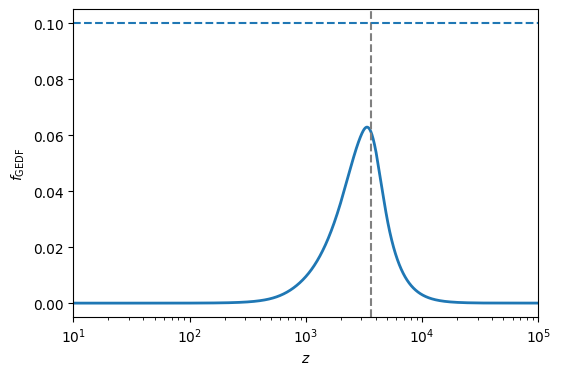

In [35]:
plt.figure(figsize=(6, 4))

plt.semilogx(model.get_background()['z'], model.get_background()['(.)rho_gedf']/(model.get_background()['(.)rho_tot']), '-', linewidth=2, label=r'test')
plt.xlabel(r'$z$')
plt.ylabel(r'$f_{\mathrm{GEDF}}$')
plt.xlim([1e1, 1e5])
plt.axvline(x = 3646, color = 'gray', linestyle = '--', label=r'$z_{\mathrm{ac}}$')
plt.axhline(y = 0.1, linestyle = '--')
plt.show()

In [32]:
all_k = model.get_perturbations()  # this potentially constains scalars/tensors and all k values
print (all_k['scalar'][0].keys())
#    
one_k = all_k['scalar'][0] 

background = model.get_background()
background_z = background['z']

dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'delta_ncdm[0]', 'theta_ncdm[0]', 'shear_ncdm[0]', 'cs2_ncdm[0]', 'delta_rho_gedf', 'rho_plus_p_theta_gedf', 'delta_p_gedf', 'delta_gedf', 'ca2_gedf_output', 'cs2_gedf_output', 'u_gedf', 'T_h_gedf'])


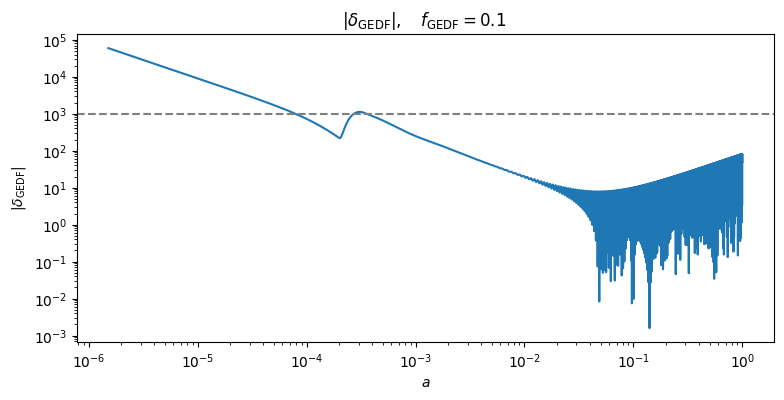

In [33]:
plt.figure(figsize=(9, 4))

plt.loglog(one_k['a'], abs(one_k['delta_gedf']))

plt.xlabel(r"$a$")
plt.ylabel(r"$|\delta_{\mathrm{GEDF}}|$")
plt.title(r"$|\delta_{\mathrm{GEDF}}|,\quad f_{\mathrm{GEDF}} = 0.1$ ")
plt.axhline(y = 1e3, color = 'gray', linestyle = '--')

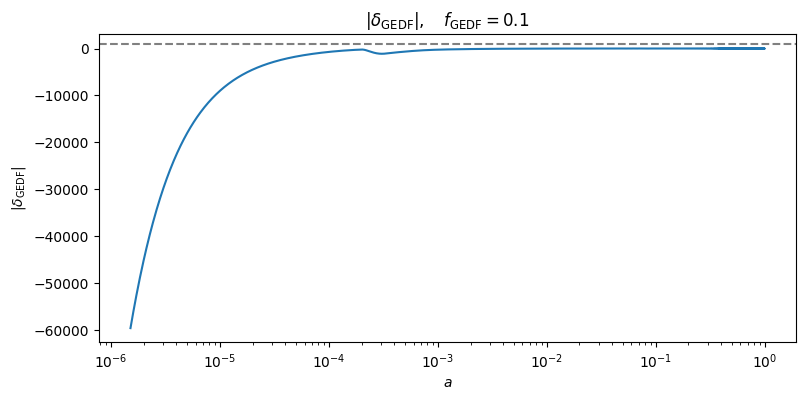

In [36]:
plt.figure(figsize=(9, 4))

plt.semilogx(one_k['a'], one_k['delta_gedf'])

plt.xlabel(r"$a$")
plt.ylabel(r"$|\delta_{\mathrm{GEDF}}|$")
plt.title(r"$|\delta_{\mathrm{GEDF}}|,\quad f_{\mathrm{GEDF}} = 0.1$ ")
plt.axhline(y = 1e3, color = 'gray', linestyle = '--')

Text(0, 0.5, '$\\delta\\rho_{\\mathrm{GEDF}}$')

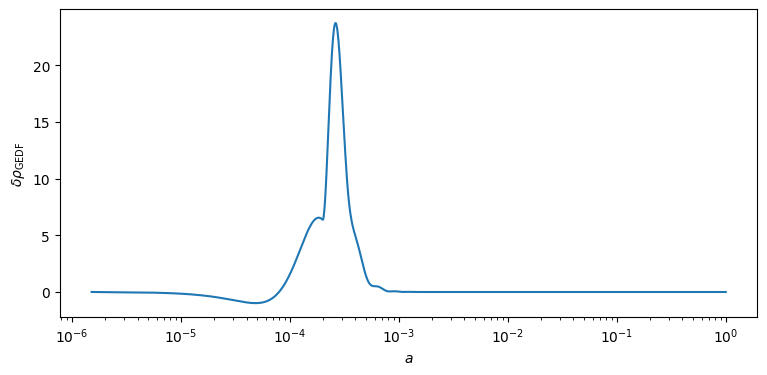

In [34]:
plt.figure(figsize=(9, 4))

plt.semilogx(one_k['a'], one_k['delta_rho_gedf'], label=r'$\delta\rho_{\mathrm{GEDF}}$')
# plt.semilogx(one_k['a'], one_k['delta_gedf_2'], label=r'$\delta_{\mathrm{GEDF}}$')
# plt.()
plt.xlabel(r"$a$")
plt.ylabel(r"$\delta\rho_{\mathrm{GEDF}}$")